In [ ]:
# Testen von ManifestoBERTa
# Modell wurde speziell für politische Texte trainiert 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from sklearn.metrics import confusion_matrix
import seaborn as sns

# First Tryouts

In [11]:
# standard versuch von ManifestoBerta als vergleich.

model = AutoModelForSequenceClassification.from_pretrained("manifesto-project/manifestoberta-xlm-roberta-56policy-topics-context-2024-1-1", trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-large")

sentence = "These principles are under threat."
context = "Human rights and international humanitarian law are fundamental pillars of a secure global system. These principles are under threat. Some of the world's most powerful states choose to sell arms to human-rights abusing states."
# For sentences without additional context, just use the sentence itself as the context.
# Example: context = "These principles are under threat."


inputs = tokenizer(sentence,
                   context,
                   return_tensors="pt",
                   max_length=512,  #we limited the input to 300 tokens during finetuning
                   padding="max_length",
                   truncation=True
                   )

logits = model(**inputs).logits

probabilities = torch.softmax(logits, dim=1).tolist()[0]
probabilities = {model.config.id2label[index]: round(probability * 100, 2) for index, probability in enumerate(probabilities)}
probabilities = dict(sorted(probabilities.items(), key=lambda item: item[1], reverse=True))
print(probabilities)
# {'201 - Freedom and Human Rights': 86.58, '107 - Internationalism: Positive': 8.12, '106 - Peace': 1.67...

predicted_class = model.config.id2label[logits.argmax().item()]
print(predicted_class)
# 201 - Freedom and Human Rights


{'201 - Freedom and Human Rights': 86.58, '107 - Internationalism: Positive': 8.12, '106 - Peace': 1.67, '105 - Military: Negative': 1.01, '202 - Democracy': 0.47, '104 - Military: Positive': 0.43, '103 - Anti-Imperialism': 0.39, '109 - Internationalism: Negative': 0.19, '305 - Political Authority': 0.19, '605 - Law and Order: Positive': 0.17, '203 - Constitutionalism: Positive': 0.07, '602 - National Way of Life: Negative': 0.07, '603 - Traditional Morality: Positive': 0.06, '503 - Equality: Positive': 0.05, '601 - National Way of Life: Positive': 0.05, '416 - Anti-Growth Economy: Positive': 0.04, '501 - Environmental Protection: Positive': 0.04, '101 - Foreign Special Relationships: Positive': 0.03, '403 - Market Regulation': 0.03, '604 - Traditional Morality: Negative': 0.03, '606 - Civic Mindedness: Positive': 0.03, '102 - Foreign Special Relationships: Negative': 0.02, '108 - European Community/Union: Positive': 0.02, '406 - Protectionism: Positive': 0.02, '504 - Welfare State Exp

In [4]:
# versuch mit SPD Text 

sentence = "Wir wollen, dass Deine Arbeit auch in der Rente ihren Wert behält."
context = "Wir sorgen dafür, dass das Niveau der gesetzlichen Rentenversicherung dauerhaft bei mindestens 48 Prozent gesichert wird. Eine Anhebung der Regelaltersgrenze lehnen wir ab. Abschlagsfreier Renteneintritt bleibt nach 45 Jahren möglich."
# For sentences without additional context, just use the sentence itself as the context.
# Example: context = "These principles are under threat."


inputs = tokenizer(sentence,
                   context,
                   return_tensors="pt",
                   max_length=512,  #we limited the input to 300 tokens during finetuning
                   padding="max_length",
                   truncation=True
                   )

logits = model(**inputs).logits

probabilities = torch.softmax(logits, dim=1).tolist()[0]
probabilities = {model.config.id2label[index]: round(probability * 100, 2) for index, probability in enumerate(probabilities)}
probabilities = dict(sorted(probabilities.items(), key=lambda item: item[1], reverse=True))
print(probabilities)
# {'201 - Freedom and Human Rights': 86.58, '107 - Internationalism: Positive': 8.12, '106 - Peace': 1.67...

predicted_class = model.config.id2label[logits.argmax().item()]
print(predicted_class)

{'504 - Welfare State Expansion': 61.46, '701 - Labour Groups: Positive': 31.58, '503 - Equality: Positive': 2.08, '505 - Welfare State Limitation': 1.97, '704 - Middle Class and Professional Groups': 0.42, '408 - Economic Goals': 0.33, '606 - Civic Mindedness: Positive': 0.31, '412 - Controlled Economy': 0.28, '401 - Free Market Economy': 0.24, '706 - Non-economic Demographic Groups': 0.19, '303 - Governmental and Administrative Efficiency': 0.17, '201 - Freedom and Human Rights': 0.09, '403 - Market Regulation': 0.09, '305 - Political Authority': 0.08, '402 - Incentives': 0.07, '414 - Economic Orthodoxy': 0.07, '601 - National Way of Life: Positive': 0.07, '603 - Traditional Morality: Positive': 0.07, '410 - Economic Growth: Positive': 0.06, '411 - Technology and Infrastructure': 0.04, '405 - Corporatism/ Mixed Economy': 0.03, '506 - Education Expansion': 0.03, '702 - Labour Groups: Negative': 0.03, '705 - Underprivileged Minority Groups': 0.03, '404 - Economic Planning': 0.02, '416 

In [5]:
# Mapping von Policy-Kategorien zu Wahlomat-Positionen
policy_to_wahlomat = {
    "504 - Welfare State Expansion": "Stimme zu",   # Sozialstaat stärken
    "505 - Welfare State Limitation": "Stimme nicht zu",  # Sozialstaat abbauen
    "701 - Labour Groups: Positive": "Stimme zu",   # Arbeitnehmerfreundlich
    "702 - Labour Groups: Negative": "Stimme nicht zu",  # Arbeitnehmer unfreundlich
}

def map_policy_to_wahlomat(predictions):
    """
    Wandelt die Policy-Kategorien des Modells in Wahlomat-Antworten um.
    """
    if not predictions:
        return "Neutral"  # Falls keine Vorhersage vorhanden ist

    # Sortiere die Predictions nach Wahrscheinlichkeit (höchster Wert zuerst)
    sorted_predictions = sorted(predictions.items(), key=lambda item: item[1], reverse=True)

    # Wähle die Top-Kategorie
    top_policy = sorted_predictions[0][0]

    # Prüfe, ob die Top-Kategorie im Mapping enthalten ist
    return policy_to_wahlomat.get(top_policy, "Neutral")

# **Beispieldaten von deinem Modell**
probabilities = {
    "504 - Welfare State Expansion": 61.46,
    "701 - Labour Groups: Positive": 31.58,
    "505 - Welfare State Limitation": 1.97,
}

# Mapping auf Wahlomat-Kategorien
wahlomat_antwort = map_policy_to_wahlomat(probabilities)

print(f"Wahlomat-Antwort: {wahlomat_antwort}")


Wahlomat-Antwort: Stimme zu


## Implementierung mit SPD

In [12]:
# Wahlomat-Thesen zu Manifesto Kategorien mappen, z.B. These 1 wird zu Welfare State Expansion gemappt 
# Wahlomat-Thesen laden
df_questions = pd.read_csv("wahlomaten_thesen_positionen.csv")

# Liste für Ergebnisse
results = []

for index, row in df_questions.iterrows():
    sentence = row["These"]
    context = sentence  # Nutzen der These selbst, als Versuch, sonst wohl text aus txt datei nehmen?

    # Tokenisierung, Max len angepasst, muss im finetuning geändert werden 
    inputs = tokenizer(sentence, context, return_tensors="pt", max_length=512, padding="max_length", truncation=True)

    # Modellvorhersage
    logits = model(**inputs).logits
    probabilities = torch.softmax(logits, dim=1).tolist()[0]
    
    # Mapping der ID zur Policy-Kategorie
    probabilities = {model.config.id2label[index]: round(probability * 100, 2) for index, probability in enumerate(probabilities)}
    probabilities = dict(sorted(probabilities.items(), key=lambda item: item[1], reverse=True))
    
    # Beste Category auswählen, könnten hier auch alle Wahrscheinlichkeiten zum Vergleich nehmen
    predicted_class = model.config.id2label[logits.argmax().item()]

    results.append({"These": sentence, "Best_Policy_Category": predicted_class, "Full_Probabilities": probabilities})

# Ergebnisse als DataFrame speichern
df_results = pd.DataFrame(results)
df_results.to_csv("wahlomat_policy_predictions.csv", index=False)

print("Wahlomat-Kategorien gespeichert in 'wahlomat_policy_predictions.csv'")


Wahlomat-Kategorien gespeichert in 'wahlomat_policy_predictions.csv'


# Implementierung

## Nur SPD

In [ ]:
# Einlesen der vorher klassifizierten Daten aus dem Wahlomat
df_wahlomat = pd.read_csv("wahlomat_policy_predictions.csv") 
df_wahlomat = df_wahlomat[["These", "Best_Policy_Category"]]  # Relevante Spalten behalten

# Einlesen der Daten aus den 
df_results_spd = df_results  # SPD-Wahlprogramm-Analysen (bereits geladen)
df_results_spd = df_results_spd[["These", "Policy_Category"]]  # Relevante Spalten behalten

# **🎯 3️⃣ Matching basierend auf der Policy-Kategorie**
def determine_spd_position(wahlomat_category, spd_categories):
    """
    Bestimmt die Haltung der SPD basierend auf der Policy-Kategorie der Wahlomat-These.
    """
    opposite_policies = {
        "504 - Welfare State Expansion": "505 - Welfare State Limitation",
        "505 - Welfare State Limitation": "504 - Welfare State Expansion",
        "701 - Labour Groups: Positive": "702 - Labour Groups: Negative",
        "702 - Labour Groups: Negative": "701 - Labour Groups: Positive",
        "406 - Protectionism: Positive": "407 - Protectionism: Negative",
        "407 - Protectionism: Negative": "406 - Protectionism: Positive",
        "506 - Education Expansion": "507 - Education Limitation",
        "507 - Education Limitation": "506 - Education Expansion",
        "401 - Free Market Economy": "412 - Controlled Economy",
        "412 - Controlled Economy": "401 - Free Market Economy"
    }

    if wahlomat_category in spd_categories:
        return "stimme zu"

    # **2️⃣ Falls eine entgegengesetzte Kategorie vorhanden ist -> "Stimme nicht zu"**
    elif wahlomat_category in opposite_policies and opposite_policies[wahlomat_category] in spd_categories:
        return "stimme nicht zu"

    # **3️⃣ Falls keine Übereinstimmung -> "Neutral"**
    else:
        return "neutral"

# **🔄 4️⃣ Gruppenbildung: Welche Policy-Kategorien kommen in SPD-Texten vor?**
spd_policy_set = set(df_results_spd["Policy_Category"].unique())  # Alle Policy-Kategorien aus dem SPD-Wahlprogramm

# **📊 5️⃣ Berechnung der SPD-Position für jede Wahlomat-These**
df_wahlomat["SPD_Model_Prediction"] = df_wahlomat["Best_Policy_Category"].apply(lambda cat: determine_spd_position(cat, spd_policy_set))

# **💾 6️⃣ Speichern der Ergebnisse**
df_wahlomat.to_csv("spd_wahlomat_policy_matching.csv", index=False)

# **📌 7️⃣ Ergebnisse ausgeben**
print("✅ Matching gespeichert in 'spd_wahlomat_policy_matching.csv'")
print(df_wahlomat[["These", "Best_Policy_Category", "SPD_Model_Prediction"]].head())


✅ Matching gespeichert in 'spd_wahlomat_policy_matching.csv'
                                               These  \
0  Alle Beschäftigten sollen bereits nach 40 Beit...   
1  Alle Bürgerinnen und Bürger sollen in gesetzli...   
2  An Bahnhöfen soll die Bundespolizei Software z...   
3  Asylsuchende sollen in Deutschland sofort nach...   
4  Asylsuchende, die über einen anderen EU-Staat ...   

                    Best_Policy_Category SPD_Model_Prediction  
0          504 - Welfare State Expansion            stimme zu  
1          504 - Welfare State Expansion            stimme zu  
2          605 - Law and Order: Positive            stimme zu  
3  705 - Underprivileged Minority Groups              neutral  
4   601 - National Way of Life: Positive              neutral  


In [46]:
df_wahlomat

,These,Best_Policy_Category,SPD_Model_Prediction
0,Alle Beschäftigten sollen bereits nach 40 Beit...,504 - Welfare State Expansion,stimme zu
1,Alle Bürgerinnen und Bürger sollen in gesetzli...,504 - Welfare State Expansion,stimme zu
2,An Bahnhöfen soll die Bundespolizei Software z...,605 - Law and Order: Positive,stimme zu
3,Asylsuchende sollen in Deutschland sofort nach...,705 - Underprivileged Minority Groups,neutral
4,"Asylsuchende, die über einen anderen EU-Staat ...",601 - National Way of Life: Positive,neutral
5,Auf allen Autobahnen soll ein generelles Tempo...,411 - Technology and Infrastructure,stimme zu
6,Aus Deutschland sollen weiterhin Rüstungsgüter...,105 - Military: Negative,neutral
7,Bei Neuvermietungen sollen die Mietpreise weit...,412 - Controlled Economy,stimme zu
8,Bei der Besteuerung von Einkommen soll der Spi...,503 - Equality: Positive,stimme zu
9,Beim Ausbau der Verkehrsinfrastruktur soll die...,411 - Technology and Infrastructure,stimme zu


C:\Users\vanes\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


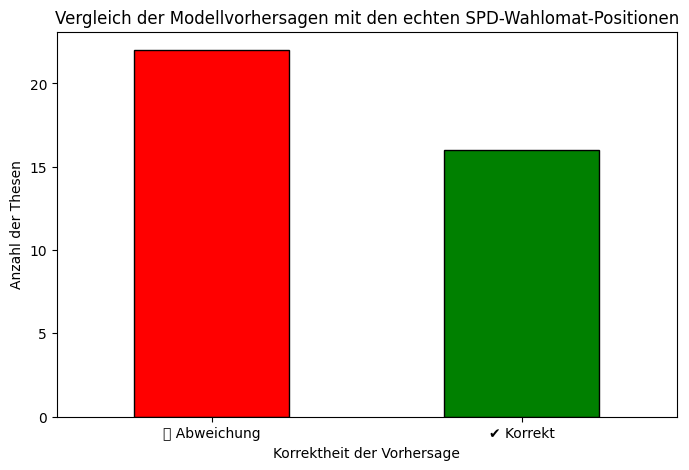

✅ Vergleich gespeichert in 'spd_wahlomat_vergleich_plot.csv'
                                               These              SPD  \
0  Alle Beschäftigten sollen bereits nach 40 Beit...  stimme nicht zu   
1  Alle Bürgerinnen und Bürger sollen in gesetzli...        stimme zu   
2  An Bahnhöfen soll die Bundespolizei Software z...  stimme nicht zu   
3  Asylsuchende sollen in Deutschland sofort nach...        stimme zu   
4  Asylsuchende, die über einen anderen EU-Staat ...  stimme nicht zu   

  SPD_Model_Prediction    Abweichung  
0            stimme zu  ❌ Abweichung  
1            stimme zu     ✔ Korrekt  
2            stimme zu  ❌ Abweichung  
3              neutral  ❌ Abweichung  
4              neutral  ❌ Abweichung  


In [ ]:
# **📂 1️⃣ Wahlomat-Daten laden (tatsächliche SPD-Positionen)**
df_wahlomat_true = pd.read_csv("wahlomaten_thesen_positionen.csv")  # Enthält tatsächliche Wahlomat-Antworten der SPD
df_wahlomat_true = df_wahlomat_true[["These", "SPD"]]  # Nur SPD-Antworten behalten

# **📂 2️⃣ Modellvorhersagen laden**
df_wahlomat_pred = pd.read_csv("spd_wahlomat_policy_matching.csv")  # Modell-Vorhersagen der SPD-Positionen
df_wahlomat_pred = df_wahlomat_pred[["These", "SPD_Model_Prediction"]]  # Nur relevante Spalten

# **🔄 3️⃣ DataFrames zusammenführen**
df_comparison = df_wahlomat_true.merge(df_wahlomat_pred, on="These", how="left")

# **📊 4️⃣ Zählen der Übereinstimmungen & Abweichungen**
df_comparison["Abweichung"] = df_comparison.apply(
    lambda row: "Korrekt" if row["SPD"] == row["SPD_Model_Prediction"] else "Abweichung", axis=1
)

# **📊 5️⃣ Plot der Ergebnisse**
plt.figure(figsize=(8,5))
df_comparison["Abweichung"].value_counts().plot(kind="bar", color=["red", "green"], edgecolor="black")

plt.title("Vergleich der Modellvorhersagen mit den echten SPD-Wahlomat-Positionen")
plt.xlabel("Korrektheit der Vorhersage")
plt.ylabel("Anzahl der Thesen")
plt.xticks(rotation=0)
plt.show()

# **💾 6️⃣ Ergebnisse speichern**
df_comparison.to_csv("spd_wahlomat_vergleich_plot.csv", index=False)

# **📌 7️⃣ Ergebnisse ausgeben**
print("✅ Vergleich gespeichert in 'spd_wahlomat_vergleich_plot.csv'")
print(df_comparison.head())


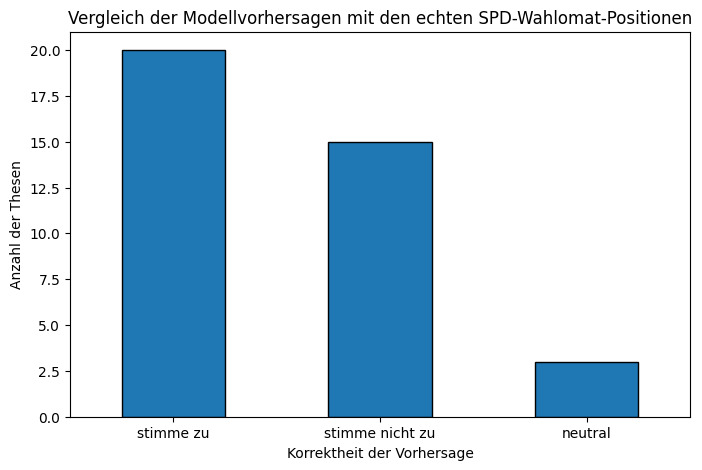

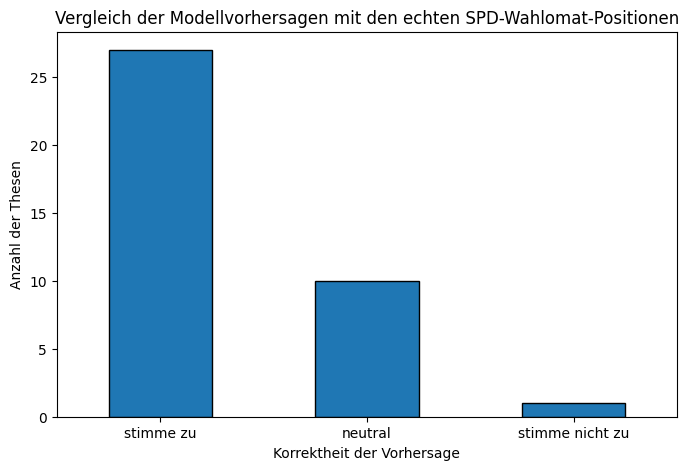

In [48]:
plt.figure(figsize=(8,5))
df_comparison["SPD"].value_counts().plot(kind="bar", edgecolor="black")

plt.title("Vergleich der Modellvorhersagen mit den echten SPD-Wahlomat-Positionen")
plt.xlabel("Korrektheit der Vorhersage")
plt.ylabel("Anzahl der Thesen")
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(8,5))
df_comparison["SPD_Model_Prediction"].value_counts().plot(kind="bar", edgecolor="black")

plt.title("Vergleich der Modellvorhersagen mit den echten SPD-Wahlomat-Positionen")
plt.xlabel("Korrektheit der Vorhersage")
plt.ylabel("Anzahl der Thesen")
plt.xticks(rotation=0)
plt.show()


## Alle Parteien

In [13]:
# Aus Text Dateien klassifizertes Dataframe erstellen
#  Manifesto Model laden 
model = AutoModelForSequenceClassification.from_pretrained(
    "manifesto-project/manifestoberta-xlm-roberta-56policy-topics-context-2024-1-1", 
    trust_remote_code=True
)
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-large")

# Parteidictonary mit text files (Mit Textfiles war aufsplitten nach These und zugehörigem Text einfacher)
party_files = {
    "SPD": "spd.txt",
    "CDU/CSU": "cdu.txt",
    "GRÜNE": "gruene.txt",
    "FDP": "fdp.txt",
    "AfD": "afd.txt",
    "Die Linke": "linke.txt"
}

# resuts df initialisieren
all_results = []


# für jede Partei die Texte klassifieren 
for party, file_path in party_files.items():
    try:
        # TXT-Datei einlesen
        with open(file_path, "r", encoding="utf-8") as file:
            lines = file.readlines()
        
        # Struktur vorbereiten
        data = []
        current_heading = None
        current_thesis = None
        current_text = None

        for line in lines:
            line = line.strip()

            if line.startswith("###"):  # Überschrift
                current_heading = line[3:].strip()
            elif line.startswith("##"):  # These
                current_thesis = line[2:].strip()
            elif line.startswith("#"):  # Text
                current_text = line[1:].strip()
                
                if current_thesis and current_text:  # Falls eine gültige These & Text vorhanden sind
                    data.append({
                        "Partei": party,
                        "Überschrift": current_heading,
                        "These": current_thesis,
                        "Text": current_text
                    })
                    
                    # Reset für nächste These
                    current_thesis = None
                    current_text = None

        # dataframe erstellen
        df_texts = pd.DataFrame(data)

        # Klassifizieren
        for index, row in df_texts.iterrows():
            thesis = row["These"]
            context = row["Text"]  # Jede These im Kontext des dazugehörigen Textes klassifizieren, hier auch bei finetuning ansetzen 

            # Modell-Vorhersage
            inputs = tokenizer(thesis, context, return_tensors="pt", max_length=512, padding="max_length", truncation=True)
            logits = model(**inputs).logits

            # Wahrscheinlichkeiten berechnen
            probabilities = torch.softmax(logits, dim=1).tolist()[0]
            predicted_class = model.config.id2label[logits.argmax().item()]

            # Ergebnisse anfügen
            all_results.append({
                "Partei": party,
                "Überschrift": row["Überschrift"],
                "These": thesis,
                "Text": context,
                "Policy_Category": predicted_class
            })
    
    except FileNotFoundError:
        print(f"File not found {file_path}")

# finale daten in df speichern
df_results = pd.DataFrame(all_results)

# als csv speichern 
df_results.to_csv("classified_text_results_all_parties.csv", index=False)

print(" Ergebnisse gespeichert")

KeyboardInterrupt: 

In [8]:
df_results

,Partei,Überschrift,These,Text,Policy_Category
0,SPD,1. Wir kämpfen für neues Wachstum und sichere ...,Wir wollen Energiepreise senken und zentrale E...,"Wir brauchen bezahlbare Energie, sonst geht un...",412 - Controlled Economy
1,SPD,1. Wir kämpfen für neues Wachstum und sichere ...,"Wir wollen, dass Unternehmen die besten Rahmen...",Wir können etwas tun für unsere Unternehmen un...,402 - Incentives
2,SPD,1. Wir kämpfen für neues Wachstum und sichere ...,Wir wollen Bürokratie abbauen und Verfahren be...,Damit unsere Wirtschaft wieder schnell in Schw...,303 - Governmental and Administrative Efficiency
3,SPD,1. Wir kämpfen für neues Wachstum und sichere ...,"Wir wollen Innovationen ermöglichen, die Deuts...",Der viel beschworene Erfndergeist in Deutschla...,411 - Technology and Infrastructure
4,SPD,2. Wir kämpfen für Made in Germany 2.0.,"Wir wollen eine stabile, breit aufgestellte un...","Unsere Unternehmen müssen sicher sein, dass si...",408 - Economic Goals
...,...,...,...,...,...
548,Die Linke,17. Für eine gerechte Einwanderungsgesellschaf...,Niemand flieht freiwillig,Das Chaos an den europäischen Grenzen ist das ...,201 - Freedom and Human Rights
549,Die Linke,17. Für eine gerechte Einwanderungsgesellschaf...,Wir sind eine Einwanderungsgesellschaft – und ...,Die großen Herausforderungen von mehr Personal...,607 - Multiculturalism: Positive
550,Die Linke,19. Medien und Kultur für eine plurale Gesells...,Kultur – vielfältig und für alle zugänglich,Der Zugang zu Kultur soll nicht vom Geldbeutel...,502 - Culture: Positive
551,Die Linke,19. Medien und Kultur für eine plurale Gesells...,Sport ist kein Luxus,Sport ist für alle da. Dafür müssen die Zugang...,503 - Equality: Positive


In [14]:
# Aus Klassifizierten Wahlomat und Partei Texten übereinstimmung analysieren
# Wahlomat-Daten
df_wahlomat = pd.read_csv("wahlomat_policy_predictions.csv")
df_wahlomat = df_wahlomat[["These", "Best_Policy_Category"]]

# Partei-Daten 
df_parties = pd.read_csv("classified_text_results_all_parties.csv")  # Enthält Positionen ALLER Parteien

# Mapping der Klassen, hier muss noch weiter geprüft werden, welche es noch gibt & ob das so richtig ist
def determine_position(wahlomat_category, party_categories):
    """
    Bestimmt die Haltung einer Partei basierend auf der Policy-Kategorie der Wahlomat-These.
    """
    opposite_policies = {
        "504 - Welfare State Expansion": "505 - Welfare State Limitation",
        "505 - Welfare State Limitation": "504 - Welfare State Expansion",
        "701 - Labour Groups: Positive": "702 - Labour Groups: Negative",
        "702 - Labour Groups: Negative": "701 - Labour Groups: Positive",
        "406 - Protectionism: Positive": "407 - Protectionism: Negative",
        "407 - Protectionism: Negative": "406 - Protectionism: Positive",
        "506 - Education Expansion": "507 - Education Limitation",
        "507 - Education Limitation": "506 - Education Expansion",
        "401 - Free Market Economy": "412 - Controlled Economy",
        "412 - Controlled Economy": "401 - Free Market Economy",
        "101 - Foreign Special Relationships: Positive": "102 - Foreign Special Relationships: Negative",
        "102 - Foreign Special Relationships: Negative": "101 - Foreign Special Relationships: Positive",
        "103 - Anti-Imperialism": "108 - European Community/Union: Positive",
        "104 - Military: Positive": "105 - Military: Negative",
        "105 - Military: Negative": "104 - Military: Positive",
        "106 - Peace": "104 - Military: Positive",
        "107 - Internationalism: Positive": "109 - Internationalism: Negative",
        "109 - Internationalism: Negative": "107 - Internationalism: Positive",
        "108 - European Community/Union: Positive": "110 - European Community/Union: Negative",
        "110 - European Community/Union: Negative": "108 - European Community/Union: Positive",
        "201 - Freedom and Human Rights": "605 - Law and Order: Positive",
        "202 - Democracy": "305 - Political Authority",
        "203 - Constitutionalism: Positive": "204 - Constitutionalism: Negative",
        "204 - Constitutionalism: Negative": "203 - Constitutionalism: Positive",
        "301 - Federalism": "302 - Centralisation",
        "302 - Centralisation": "301 - Federalism",
        "303 - Governmental and Administrative Efficiency": "304 - Political Corruption",
        "304 - Political Corruption": "303 - Governmental and Administrative Efficiency",
        "305 - Political Authority": "202 - Democracy",
        "402 - Incentives: Positive": "409 - Keynesian Demand Management",
        "409 - Keynesian Demand Management": "402 - Incentives: Positive",
        "403 - Market Regulation": "404 - Economic Planning",
        "404 - Economic Planning": "403 - Market Regulation",
        "405 - Corporatism/ Mixed Economy": "401 - Free Market Economy",
        "410 - Economic Growth: Positive": "416 - Anti-Growth Economy: Positive",
        "416 - Anti-Growth Economy: Positive": "410 - Economic Growth: Positive",
        "501 - Environmental Protection: Positive": "502 - Culture: Positive",
        "601 - National Way of Life: Positive": "602 - National Way of Life: Negative",
        "602 - National Way of Life: Negative": "601 - National Way of Life: Positive",
        "603 - Traditional Morality: Positive": "604 - Traditional Morality: Negative",
        "604 - Traditional Morality: Negative": "603 - Traditional Morality: Positive",
        "605 - Law and Order: Positive": "201 - Freedom and Human Rights",
        "606 - Civic Mindedness: Positive": "604 - Traditional Morality: Negative",
        "607 - Multiculturalism: Positive": "608 - Multiculturalism: Negative",
        "608 - Multiculturalism: Negative": "607 - Multiculturalism: Positive",
        "704 - Middle Class and Professional Groups": "705 - Underprivileged Minority Groups",
        "705 - Underprivileged Minority Groups": "704 - Middle Class and Professional Groups"
    }


    if wahlomat_category in party_categories:
        return "stimme zu"
    elif wahlomat_category in opposite_policies and opposite_policies[wahlomat_category] in party_categories:
        return "stimme nicht zu"
    else:
        return "neutral"

party_names = df_parties["Partei"].unique()  # Alle Parteien im Datensatz

# Neuen DataFrame vorbereiten
df_wahlomat_results = df_wahlomat.copy()

for party in party_names:
    # Kategorien für die aktuelle Partei
    party_policy_set = set(df_parties[df_parties["Partei"] == party]["Policy_Category"].unique())

    # Partei-Position für jede Wahlomat-These
    df_wahlomat_results[f"{party}_Model_Prediction"] = df_wahlomat_results["Best_Policy_Category"].apply(
        lambda cat: determine_position(cat, party_policy_set)
    )


df_wahlomat_results.to_csv("all_parties_wahlomat_policy_matching.csv", index=False)


In [15]:
df_wahlomat_results

,These,Best_Policy_Category,SPD_Model_Prediction,CDU/CSU_Model_Prediction,GRÜNE_Model_Prediction,FDP_Model_Prediction,AfD_Model_Prediction,Die Linke_Model_Prediction
0,Alle Beschäftigten sollen bereits nach 40 Beit...,504 - Welfare State Expansion,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu
1,Alle Bürgerinnen und Bürger sollen in gesetzli...,504 - Welfare State Expansion,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu
2,An Bahnhöfen soll die Bundespolizei Software z...,605 - Law and Order: Positive,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu
3,Asylsuchende sollen in Deutschland sofort nach...,705 - Underprivileged Minority Groups,neutral,stimme nicht zu,neutral,neutral,stimme nicht zu,stimme zu
4,"Asylsuchende, die über einen anderen EU-Staat ...",601 - National Way of Life: Positive,neutral,stimme zu,stimme nicht zu,stimme zu,stimme zu,neutral
5,Auf allen Autobahnen soll ein generelles Tempo...,411 - Technology and Infrastructure,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu
6,Aus Deutschland sollen weiterhin Rüstungsgüter...,105 - Military: Negative,stimme nicht zu,stimme nicht zu,stimme zu,stimme nicht zu,stimme nicht zu,neutral
7,Bei Neuvermietungen sollen die Mietpreise weit...,412 - Controlled Economy,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu,stimme zu,stimme zu
8,Bei der Besteuerung von Einkommen soll der Spi...,503 - Equality: Positive,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu
9,Beim Ausbau der Verkehrsinfrastruktur soll die...,411 - Technology and Infrastructure,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu


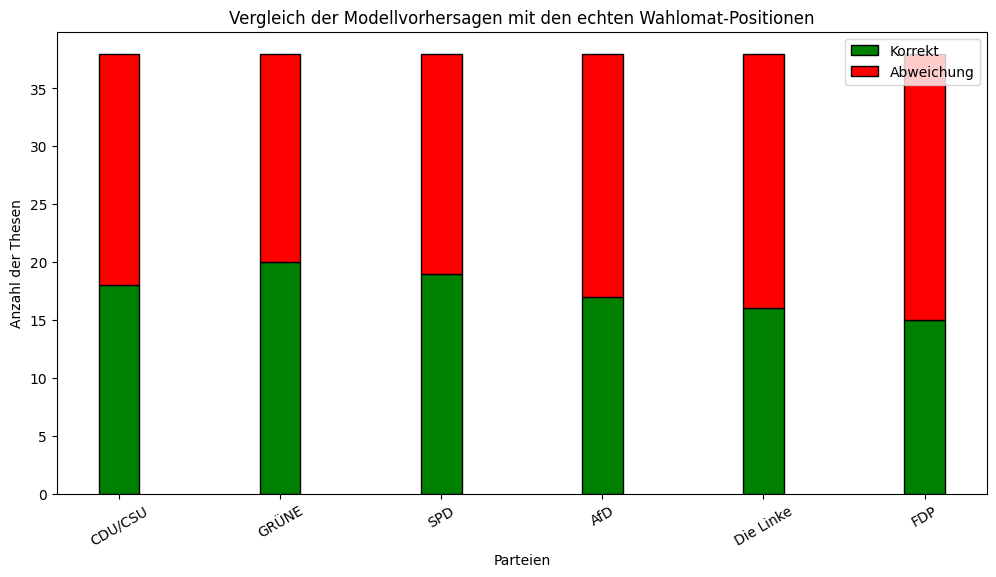

In [16]:
# Visualisieren der Ergebnisse

#  Wahlomat-Daten (Original // True Werte)
df_wahlomat_true = pd.read_csv("wahlomaten_thesen_positionen.csv")  # Enthält tatsächliche Wahlomat-Antworten
df_wahlomat_true = df_wahlomat_true.rename(columns={"CDU / CSU": "CDU/CSU"})  
df_wahlomat_true = df_wahlomat_true[["These", "CDU/CSU", "GRÜNE", "SPD", "AfD", "Die Linke", "FDP"]]  # Nur relevante Spalten behalten

# Predictions für Parteien --> These entspricht hier der Wahlomat These
df_wahlomat_pred = pd.read_csv("all_parties_wahlomat_policy_matching.csv")  # Modell-Vorhersagen der Parteien


df_comparison = df_wahlomat_true.merge(df_wahlomat_pred, on="These", how="left")

# Übereinstimmungen prüfen 
parties = ["CDU/CSU", "GRÜNE", "SPD", "AfD", "Die Linke", "FDP"]

results = {}
for party in parties:
    model_col = f"{party}_Model_Prediction"  
    df_comparison[f"Abweichung_{party}"] = df_comparison.apply(
        lambda row: "Korrekt" if row[party] == row[model_col] else "Abweichung", axis=1
    )
    results[party] = df_comparison[f"Abweichung_{party}"].value_counts()

# Plot 
plt.figure(figsize=(12, 6))
bar_width = 0.25
index = range(len(parties)) 

# Balkendiagramm für jede Partei
correct_counts = [results[party].get("Korrekt", 0) for party in parties]
incorrect_counts = [results[party].get("Abweichung", 0) for party in parties]

plt.bar(index, correct_counts, bar_width, label="Korrekt", color="green", edgecolor="black")
plt.bar(index, incorrect_counts, bar_width, bottom=correct_counts, label="Abweichung", color="red", edgecolor="black")

plt.title("Vergleich der Modellvorhersagen mit den echten Wahlomat-Positionen")
plt.xlabel("Parteien")
plt.ylabel("Anzahl der Thesen")
plt.xticks(index, parties, rotation=30)
plt.legend(loc="upper right")
plt.show()

# Ergebnisse speichern
df_comparison.to_csv("all_parties_wahlomat_vergleich_plot.csv", index=False)


In [17]:
df_wahlomat_pred

,These,Best_Policy_Category,SPD_Model_Prediction,CDU/CSU_Model_Prediction,GRÜNE_Model_Prediction,FDP_Model_Prediction,AfD_Model_Prediction,Die Linke_Model_Prediction
0,Alle Beschäftigten sollen bereits nach 40 Beit...,504 - Welfare State Expansion,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu
1,Alle Bürgerinnen und Bürger sollen in gesetzli...,504 - Welfare State Expansion,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu
2,An Bahnhöfen soll die Bundespolizei Software z...,605 - Law and Order: Positive,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu
3,Asylsuchende sollen in Deutschland sofort nach...,705 - Underprivileged Minority Groups,neutral,stimme nicht zu,neutral,neutral,stimme nicht zu,stimme zu
4,"Asylsuchende, die über einen anderen EU-Staat ...",601 - National Way of Life: Positive,neutral,stimme zu,stimme nicht zu,stimme zu,stimme zu,neutral
5,Auf allen Autobahnen soll ein generelles Tempo...,411 - Technology and Infrastructure,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu
6,Aus Deutschland sollen weiterhin Rüstungsgüter...,105 - Military: Negative,stimme nicht zu,stimme nicht zu,stimme zu,stimme nicht zu,stimme nicht zu,neutral
7,Bei Neuvermietungen sollen die Mietpreise weit...,412 - Controlled Economy,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu,stimme zu,stimme zu
8,Bei der Besteuerung von Einkommen soll der Spi...,503 - Equality: Positive,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu
9,Beim Ausbau der Verkehrsinfrastruktur soll die...,411 - Technology and Infrastructure,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu


In [79]:
df_comparison

,These,CDU/CSU,GRÜNE,SPD,AfD,Die Linke,FDP,Best_Policy_Category,SPD_Model_Prediction,CDU/CSU_Model_Prediction,GRÜNE_Model_Prediction,FDP_Model_Prediction,AfD_Model_Prediction,Die Linke_Model_Prediction,Abweichung_CDU/CSU,Abweichung_GRÜNE,Abweichung_SPD,Abweichung_AfD,Abweichung_Die Linke,Abweichung_FDP
0,Alle Beschäftigten sollen bereits nach 40 Beit...,stimme nicht zu,stimme nicht zu,stimme nicht zu,stimme nicht zu,stimme zu,stimme nicht zu,504 - Welfare State Expansion,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,Abweichung,Abweichung,Abweichung,Abweichung,Korrekt,Abweichung
1,Alle Bürgerinnen und Bürger sollen in gesetzli...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu,504 - Welfare State Expansion,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,Abweichung,Korrekt,Korrekt,Abweichung,Korrekt,Abweichung
2,An Bahnhöfen soll die Bundespolizei Software z...,stimme zu,stimme nicht zu,stimme nicht zu,stimme zu,stimme nicht zu,stimme nicht zu,605 - Law and Order: Positive,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,Korrekt,Abweichung,Abweichung,Korrekt,Abweichung,Abweichung
3,Asylsuchende sollen in Deutschland sofort nach...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,neutral,705 - Underprivileged Minority Groups,neutral,neutral,neutral,neutral,neutral,stimme zu,Abweichung,Abweichung,Abweichung,Abweichung,Korrekt,Korrekt
4,"Asylsuchende, die über einen anderen EU-Staat ...",stimme zu,stimme nicht zu,stimme nicht zu,stimme zu,stimme nicht zu,stimme zu,601 - National Way of Life: Positive,neutral,stimme zu,neutral,stimme zu,stimme zu,neutral,Korrekt,Abweichung,Abweichung,Korrekt,Abweichung,Korrekt
5,Auf allen Autobahnen soll ein generelles Tempo...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu,411 - Technology and Infrastructure,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,Abweichung,Korrekt,Korrekt,Abweichung,Korrekt,Abweichung
6,Aus Deutschland sollen weiterhin Rüstungsgüter...,stimme zu,stimme zu,stimme zu,neutral,stimme nicht zu,stimme zu,105 - Military: Negative,neutral,neutral,stimme zu,neutral,neutral,neutral,Abweichung,Korrekt,Abweichung,Korrekt,Abweichung,Abweichung
7,Bei Neuvermietungen sollen die Mietpreise weit...,stimme zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu,412 - Controlled Economy,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu,stimme zu,stimme zu,Abweichung,Korrekt,Korrekt,Abweichung,Korrekt,Korrekt
8,Bei der Besteuerung von Einkommen soll der Spi...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu,503 - Equality: Positive,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,Abweichung,Korrekt,Korrekt,Abweichung,Korrekt,Abweichung
9,Beim Ausbau der Verkehrsinfrastruktur soll die...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu,411 - Technology and Infrastructure,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,Abweichung,Korrekt,Korrekt,Abweichung,Korrekt,Abweichung


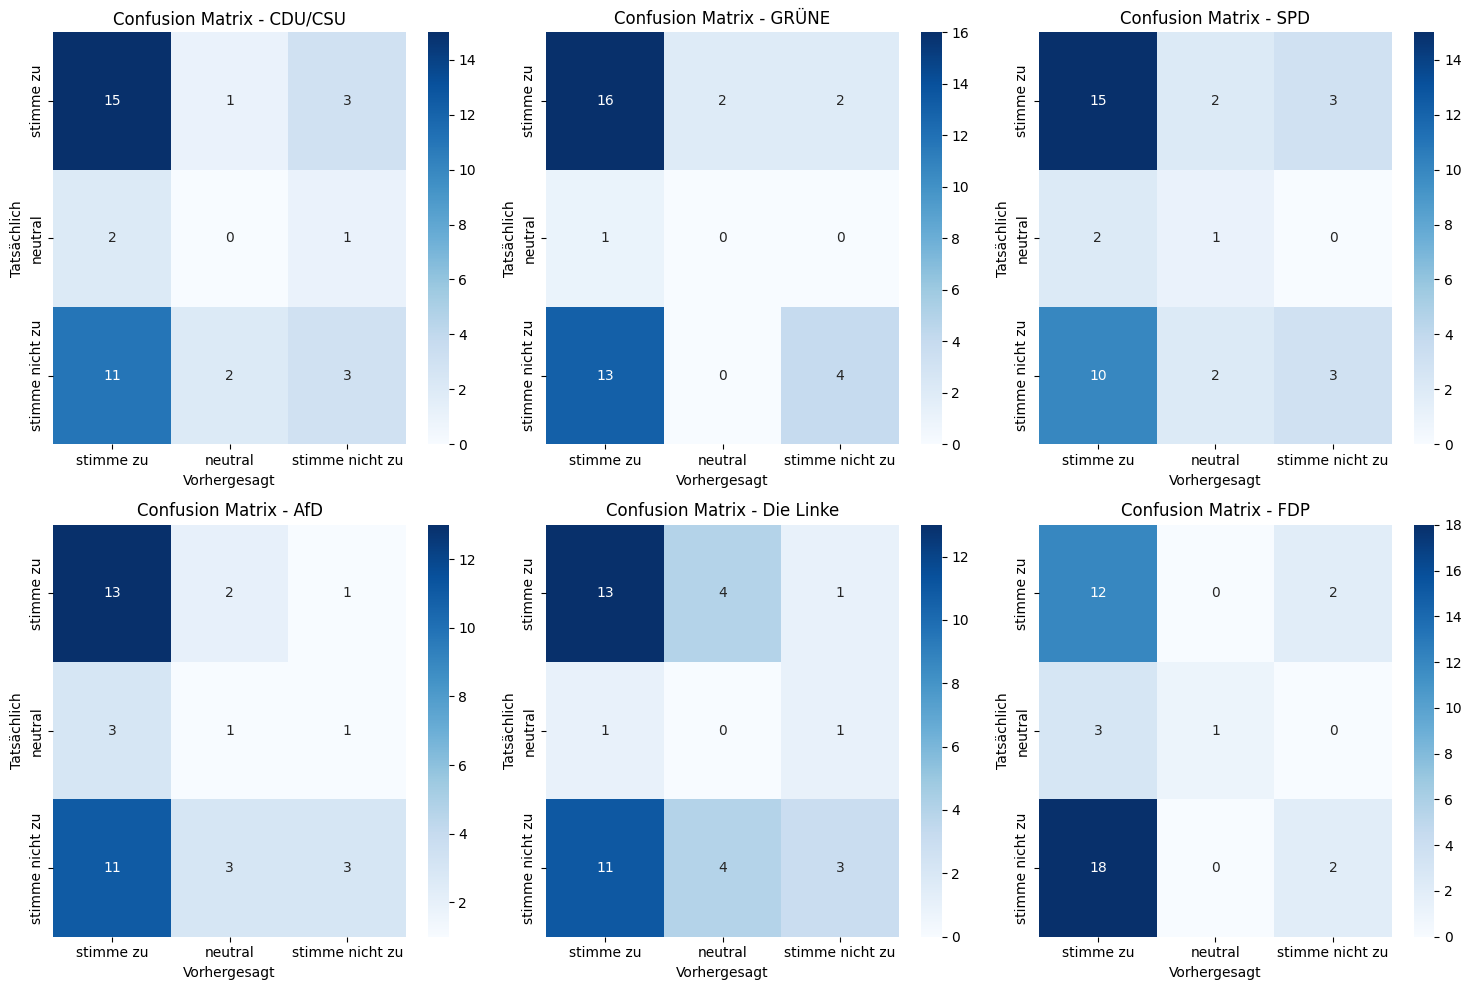

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 Reihen, 3 Spalten für Parteien

for i, party in enumerate(parties):
    model_col = f"{party}_Model_Prediction"

    # **Erstellen der Confusion Matrix**
    cm = confusion_matrix(df_comparison[party], df_comparison[model_col], labels=["stimme zu", "neutral", "stimme nicht zu"])
    
    # **Visualisierung der Confusion Matrix mit Seaborn**
    ax = axes[i // 3, i % 3]  # Positionierung im Grid
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["stimme zu", "neutral", "stimme nicht zu"], 
                yticklabels=["stimme zu", "neutral", "stimme nicht zu"], ax=ax)
    
    ax.set_title(f"Confusion Matrix - {party}")
    ax.set_xlabel("Vorhergesagt")
    ax.set_ylabel("Tatsächlich")

plt.tight_layout()